# Graph SLAM demo

**Note:** this is a new notebook written for this refactor -- it was not reconstructed from the original Udacity HTML exports (those could not be faithfully converted back into an executable notebook, since HTML exports drop the underlying `.ipynb` cell/output structure). It's a thin, interactive wrapper around the `graph_slam` package; the same steps run non-interactively via `python -m graph_slam.cli`.

This notebook simulates a robot moving through a 2D world, senses nearby landmarks with noise, runs the Graph SLAM solver, and compares the estimate against the (otherwise hidden) ground truth.

In [1]:
from graph_slam.world import simulate
from graph_slam.solver import slam, extract_poses_and_landmarks
from graph_slam.metrics import pose_rmse, landmark_rmse, final_pose_error
from graph_slam.viz import plot_comparison

SEED = 42
NUM_STEPS = 20
NUM_LANDMARKS = 5
WORLD_SIZE = 100.0
MEASUREMENT_RANGE = 50.0
MOTION_NOISE = 2.0
MEASUREMENT_NOISE = 2.0
DISTANCE = 20.0

In [2]:
result = simulate(
    num_steps=NUM_STEPS,
    num_landmarks=NUM_LANDMARKS,
    world_size=WORLD_SIZE,
    measurement_range=MEASUREMENT_RANGE,
    motion_noise=MOTION_NOISE,
    measurement_noise=MEASUREMENT_NOISE,
    distance=DISTANCE,
    seed=SEED,
)

print(f"true final pose:  ({result.true_poses[-1][0]:.3f}, {result.true_poses[-1][1]:.3f})")
print(f"true landmarks:   {[tuple(round(v, 3) for v in lm) for lm in result.true_landmarks]}")

true final pose:  (88.521, 49.712)
true landmarks:   [(64, 3), (28, 22), (74, 68), (89, 9), (42, 3)]


## Run the solver

`slam()` never sees `result.true_poses` or `result.true_landmarks` -- only `result.data` (the noisy motion/measurement stream). Ground truth is used below purely to *evaluate* the estimate.

In [3]:
mu = slam(
    data=result.data,
    num_steps=NUM_STEPS,
    num_landmarks=NUM_LANDMARKS,
    world_size=WORLD_SIZE,
    motion_noise=MOTION_NOISE,
    measurement_noise=MEASUREMENT_NOISE,
)
estimated_poses, estimated_landmarks = extract_poses_and_landmarks(mu, NUM_STEPS, NUM_LANDMARKS)

print(f"estimated final pose: ({estimated_poses[-1][0]:.3f}, {estimated_poses[-1][1]:.3f})")
print(f"estimated landmarks:  {[tuple(round(v, 3) for v in lm) for lm in estimated_landmarks]}")

estimated final pose: (86.421, 48.068)
estimated landmarks:  [(63.258, 2.869), (27.75, 22.241), (73.023, 67.579), (88.392, 9.941), (41.074, 3.132)]


In [4]:
print(f"pose RMSE:        {pose_rmse(estimated_poses, result.true_poses):.3f}")
print(f"landmark RMSE:    {landmark_rmse(estimated_landmarks, result.true_landmarks):.3f}")
print(f"final pose error: {final_pose_error(estimated_poses[-1], result.true_poses[-1]):.3f}")

pose RMSE:        1.419
landmark RMSE:    0.889
final pose error: 2.666


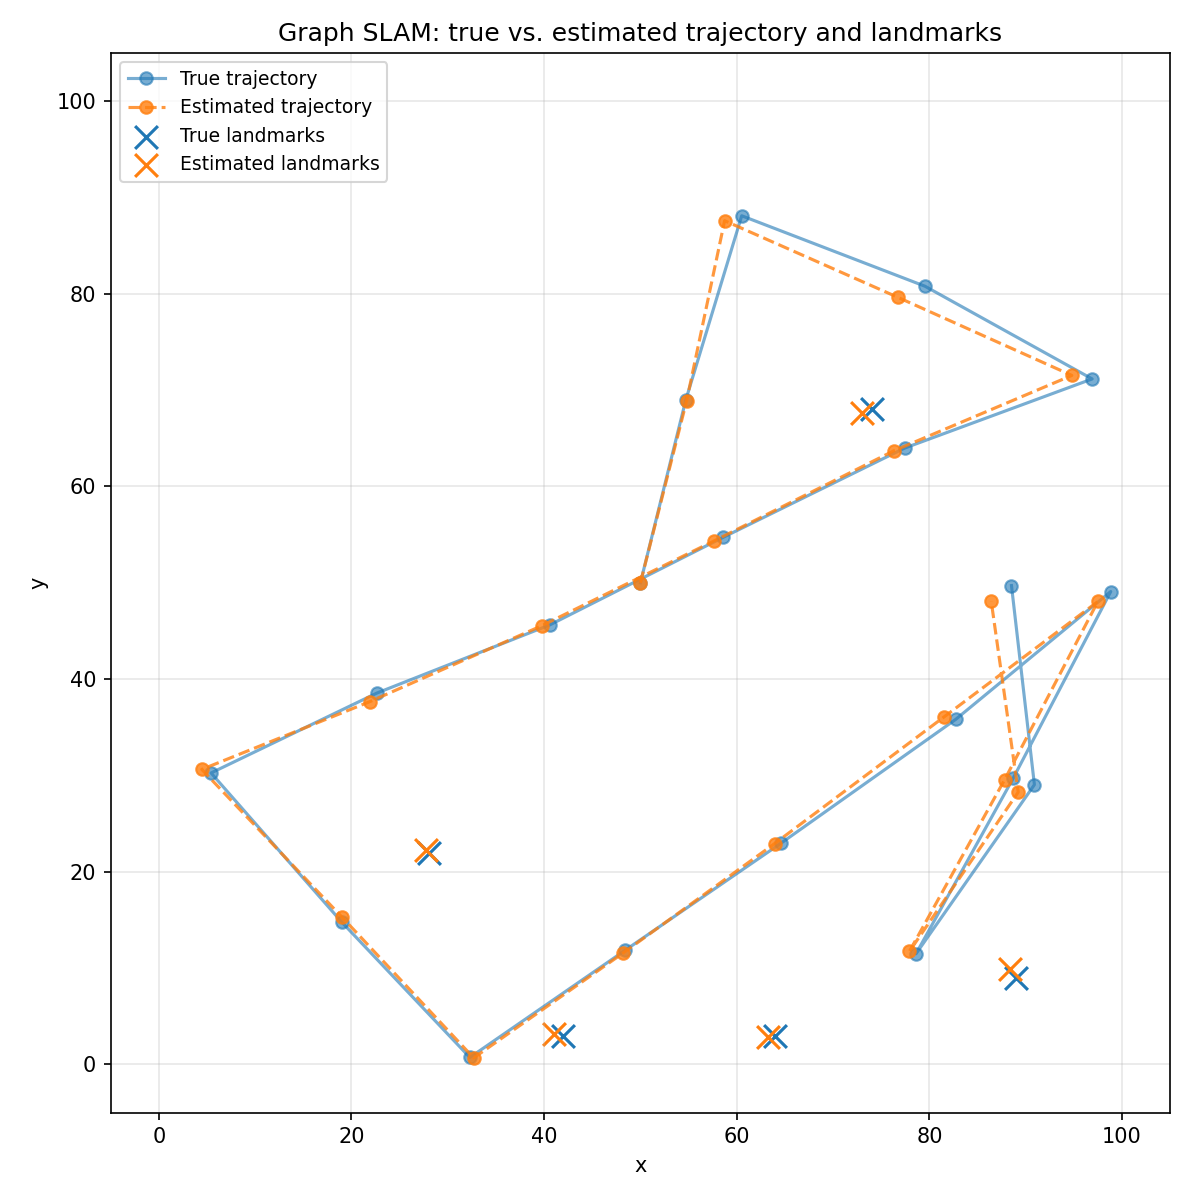

In [5]:
from IPython.display import Image

figure_path = plot_comparison(
    true_poses=result.true_poses,
    estimated_poses=estimated_poses,
    true_landmarks=result.true_landmarks,
    estimated_landmarks=estimated_landmarks,
    world_size=WORLD_SIZE,
    save_path="../results/demo_trajectory.png",
)
Image(filename=str(figure_path))